<a href="https://colab.research.google.com/github/PALAK7890/SectionA_Team14_JobMarketTrends/blob/main/03_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency

# Global Visual Settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Loading the dataset
data_url = 'https://raw.githubusercontent.com/PALAK7890/SectionA_Team14_JobMarketTrends/refs/heads/main/Dataset/postings_tableau_ready.csv'
df = pd.read_csv(data_url)

print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')
display(df.head())

Dataset loaded successfully.
Shape: (120484, 26)


,job_id,company_name,title,job_category,formatted_experience_level,formatted_work_type,remote_label,location,state,normalized_salary,...,application_type,listing_month,listing_month_name,listing_year,listing_dayofweek,original_listed_date,expiry_date,experience_order,salary_bracket_order,month_order
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Marketing,Unspecified,Full-time,On-Site,"Princeton, NJ",NJ,38480.0,...,ComplexOnsiteApply,4,Apr,2024,Wednesday,2024-04-17,2024-05-17,7,1,5
1,10998357,The National Exemplar,Assitant Restaurant Manager,Management,Unspecified,Full-time,On-Site,"Cincinnati, OH",OH,55000.0,...,ComplexOnsiteApply,4,Apr,2024,Tuesday,2024-04-16,2024-05-16,7,2,5
2,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Other,Unspecified,Full-time,On-Site,"New Hyde Park, NY",NY,157500.0,...,ComplexOnsiteApply,4,Apr,2024,Friday,2024-04-12,2024-05-12,7,6,5
3,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,Other,Unspecified,Internship,On-Site,"Raleigh, NC",NC,35360.0,...,ComplexOnsiteApply,4,Apr,2024,Thursday,2024-04-18,2024-05-18,7,1,5
4,103254301,Raw Cereal,Producer,Other,Unspecified,Contract,Remote,United States,National,180000.0,...,SimpleOnsiteApply,4,Apr,2024,Thursday,2024-04-11,2024-05-11,7,6,5


In [33]:
# Data Overview
print("--- Dataset Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Unique Values per Column ---")
print(df.nunique())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120484 entries, 0 to 120483
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      120484 non-null  int64  
 1   company_name                120484 non-null  object 
 2   title                       120484 non-null  object 
 3   job_category                120484 non-null  object 
 4   formatted_experience_level  120484 non-null  object 
 5   formatted_work_type         120484 non-null  object 
 6   remote_label                120484 non-null  object 
 7   location                    120484 non-null  object 
 8   state                       120484 non-null  object 
 9   normalized_salary           35081 non-null   float64
 10  salary_bracket              120484 non-null  object 
 11  pay_period                  120484 non-null  object 
 12  views                       120484 non-null  int64 

## 1. UNIVARIATE ANALYSIS

In this section, we examine individual variables to understand their distributions and identify potential outliers.

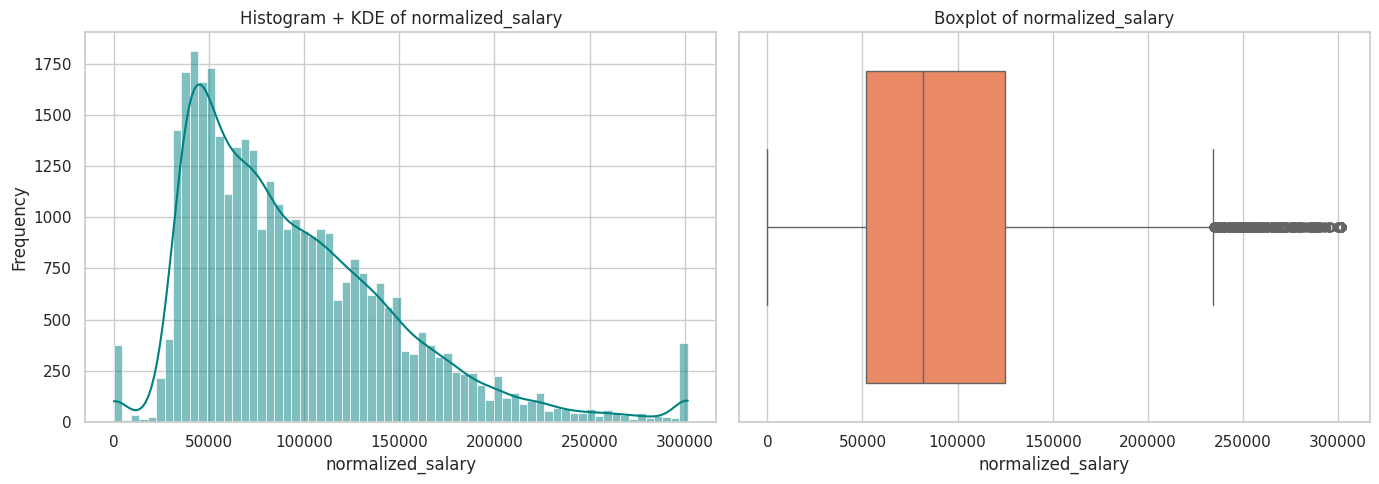

normalized_salary Skewness: 1.21


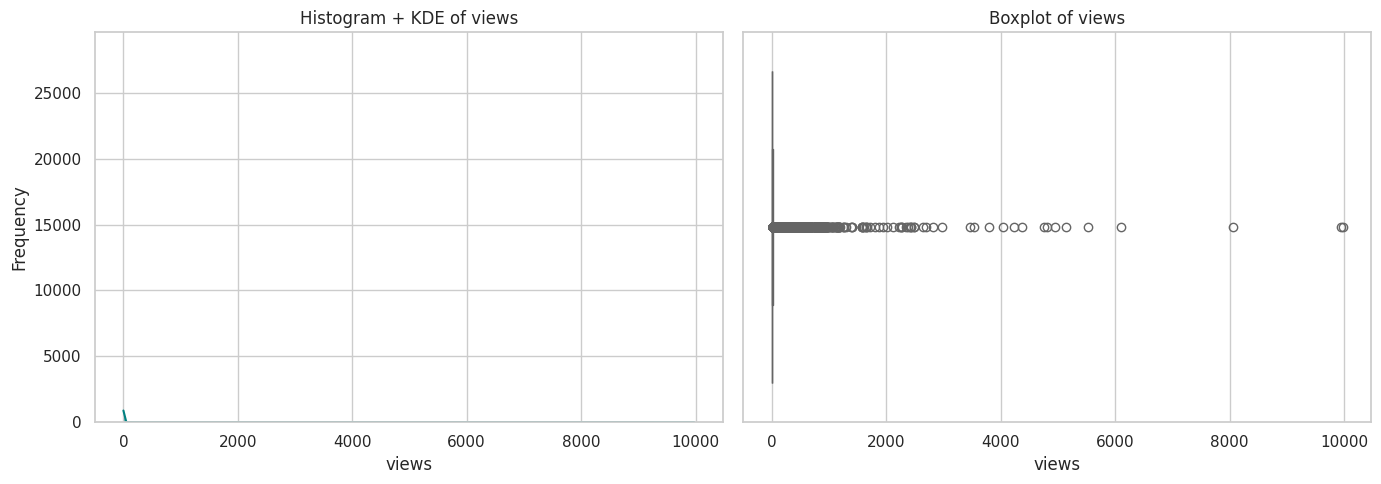

views Skewness: 53.78


In [23]:
numeric_cols = ['normalized_salary', 'views']

for col in numeric_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution
    sns.histplot(df[col], kde=True, ax=ax1, color='teal')
    ax1.set_title(f'Histogram + KDE of {col}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')

    # Outliers
    sns.boxplot(x=df[col], ax=ax2, color='coral')
    ax2.set_title(f'Boxplot of {col}')
    ax2.set_xlabel(col)

    plt.tight_layout()
    plt.show()

    print(f"{col} Skewness: {df[col].skew():.2f}")

**Insight:** Numeric features like `normalized_salary` and `views` exhibit significant right-skewness, suggesting a high volume of standard postings and a small number of high-value/highly-viewed outliers.

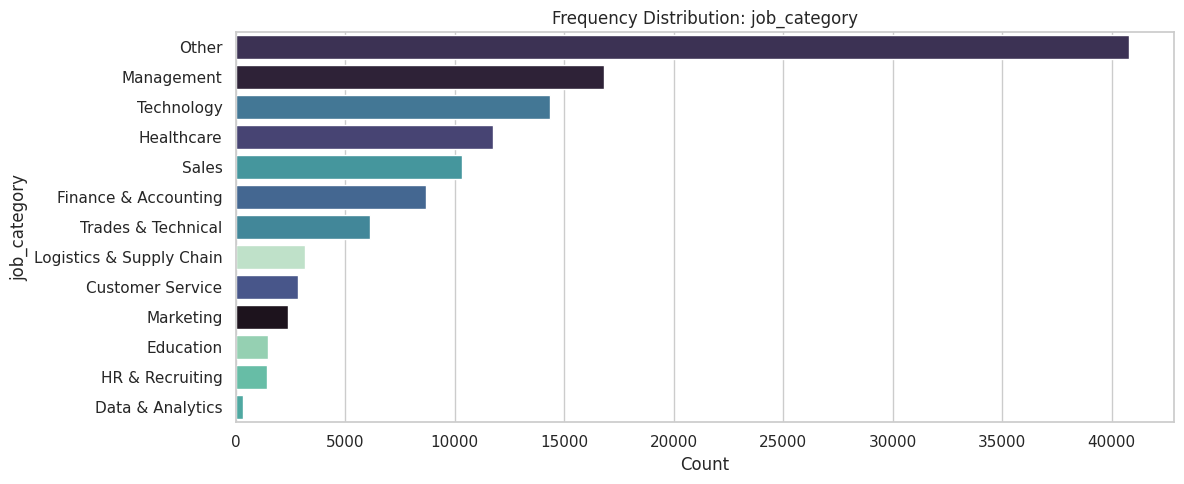

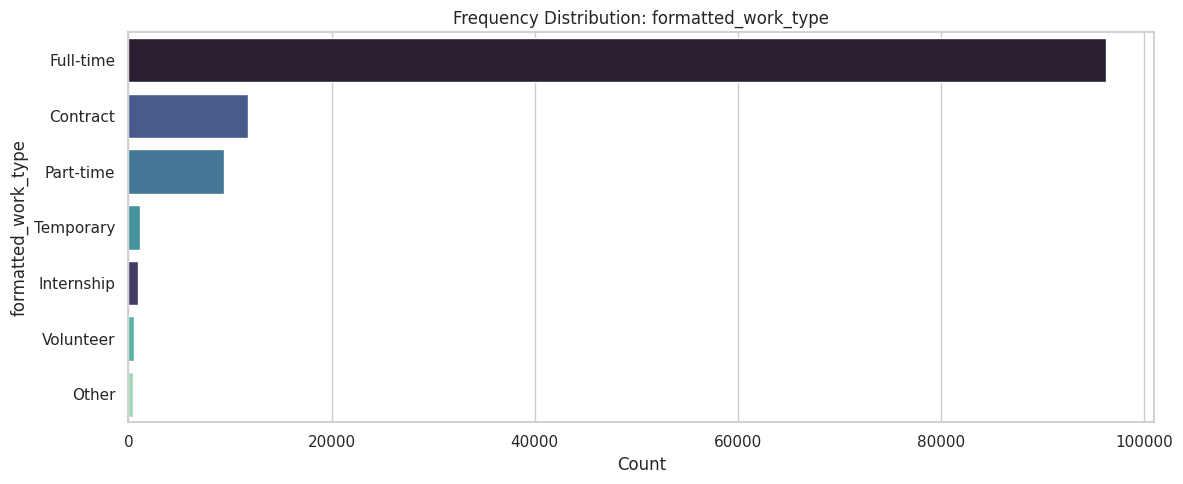

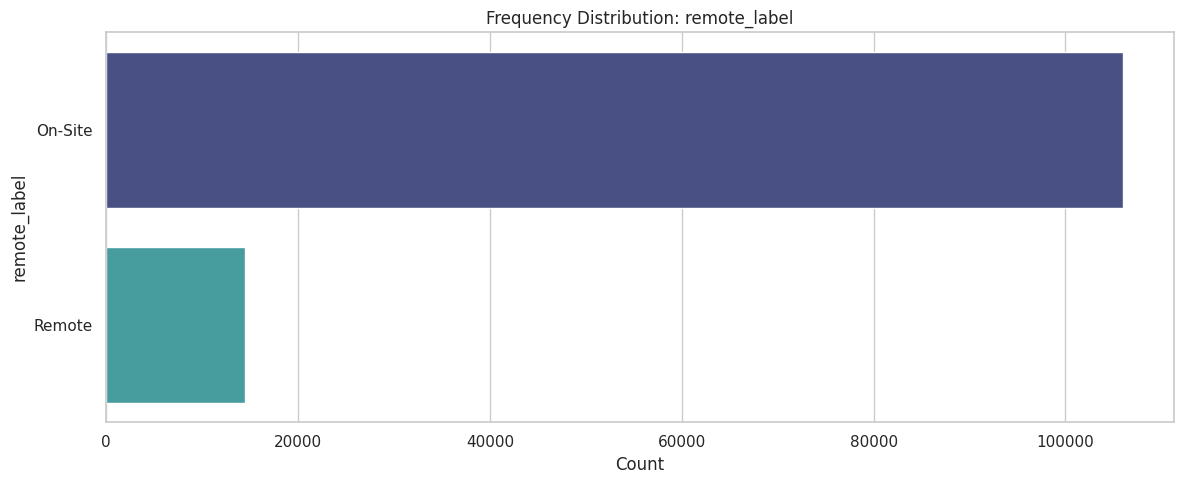

In [24]:
categorical_cols = ['job_category', 'formatted_work_type', 'remote_label']

for col in categorical_cols:
    plt.figure(figsize=(12, 5))
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, palette='mako', hue=col, legend=False)
    plt.title(f'Frequency Distribution: {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 2. BIVARIATE ANALYSIS

Exploring the relationship between experience levels, work types, and compensation.

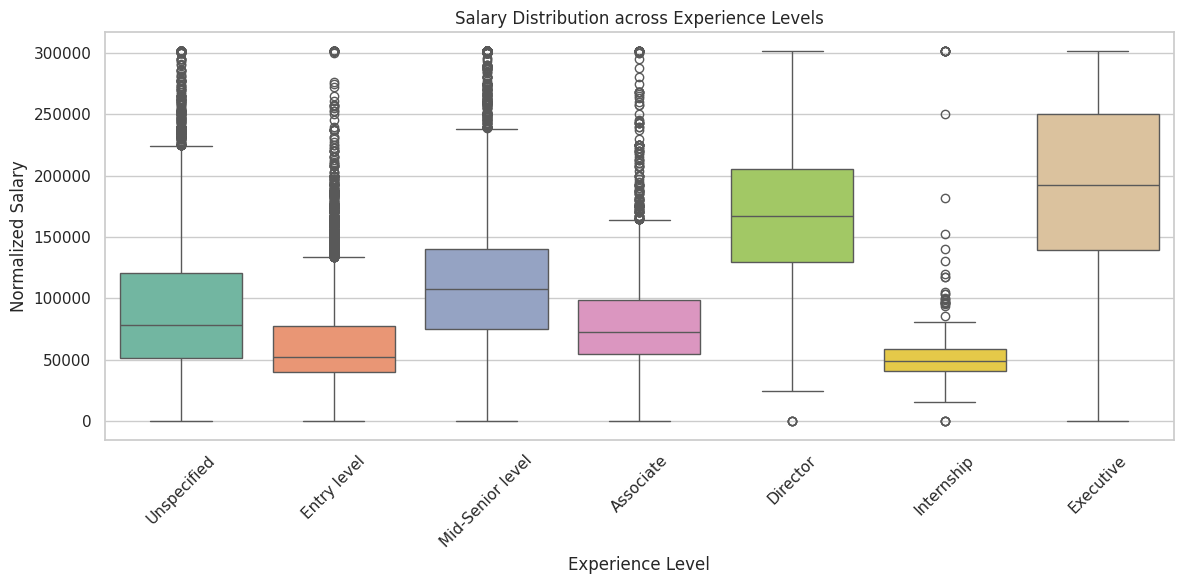

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='formatted_experience_level', y='normalized_salary', palette='Set2', hue='formatted_experience_level', legend=False)
plt.xticks(rotation=45)
plt.title('Salary Distribution across Experience Levels')
plt.xlabel('Experience Level')
plt.ylabel('Normalized Salary')
plt.tight_layout()
plt.show()

### Categorical Columns
We'll analyze frequency distributions and identify dominant or rare categories.

In [26]:
**Insight:** Salary increases noticeably with formal experience levels, though 'Unspecified' levels contain a wide range of outliers, potentially masking senior-level roles.

SyntaxError: invalid syntax (2853063012.py, line 1)

## 3. MULTIVARIATE ANALYSIS

Analyzing complex patterns across multiple variables using correlations.

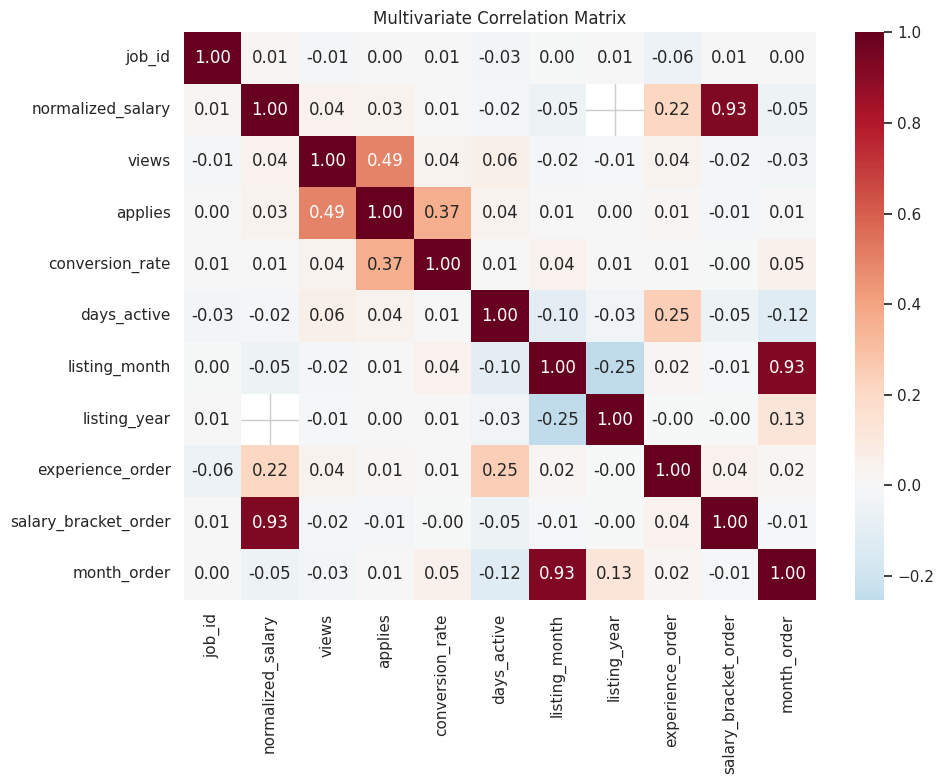

In [27]:
numeric_data = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Multivariate Correlation Matrix')
plt.tight_layout()
plt.show()

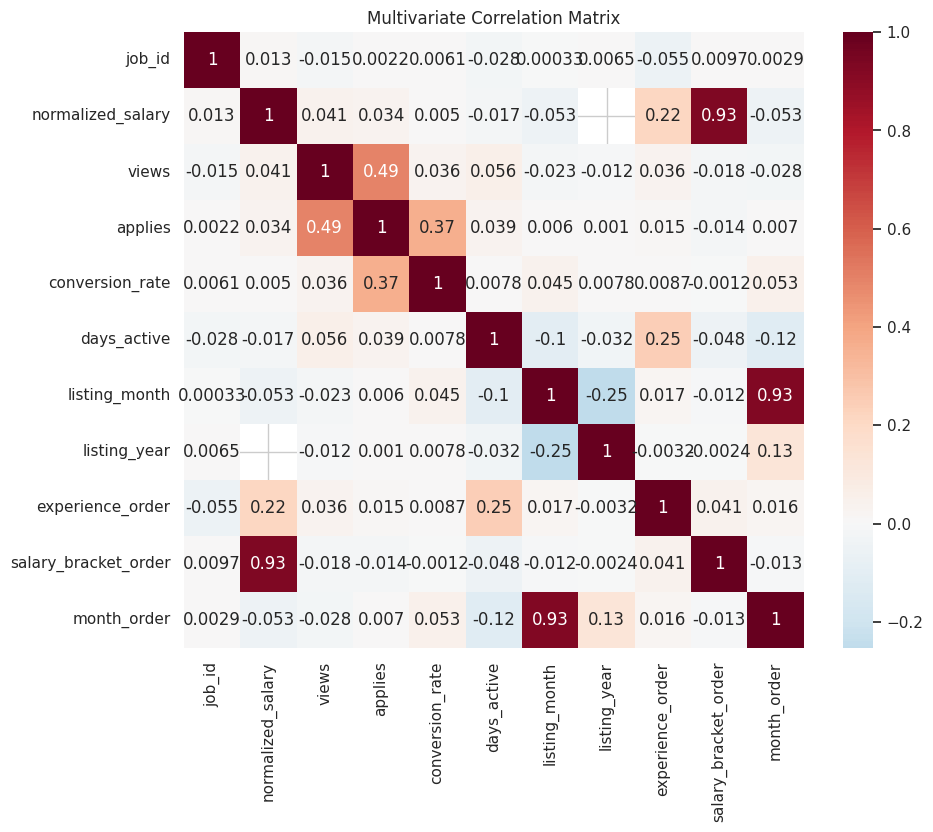

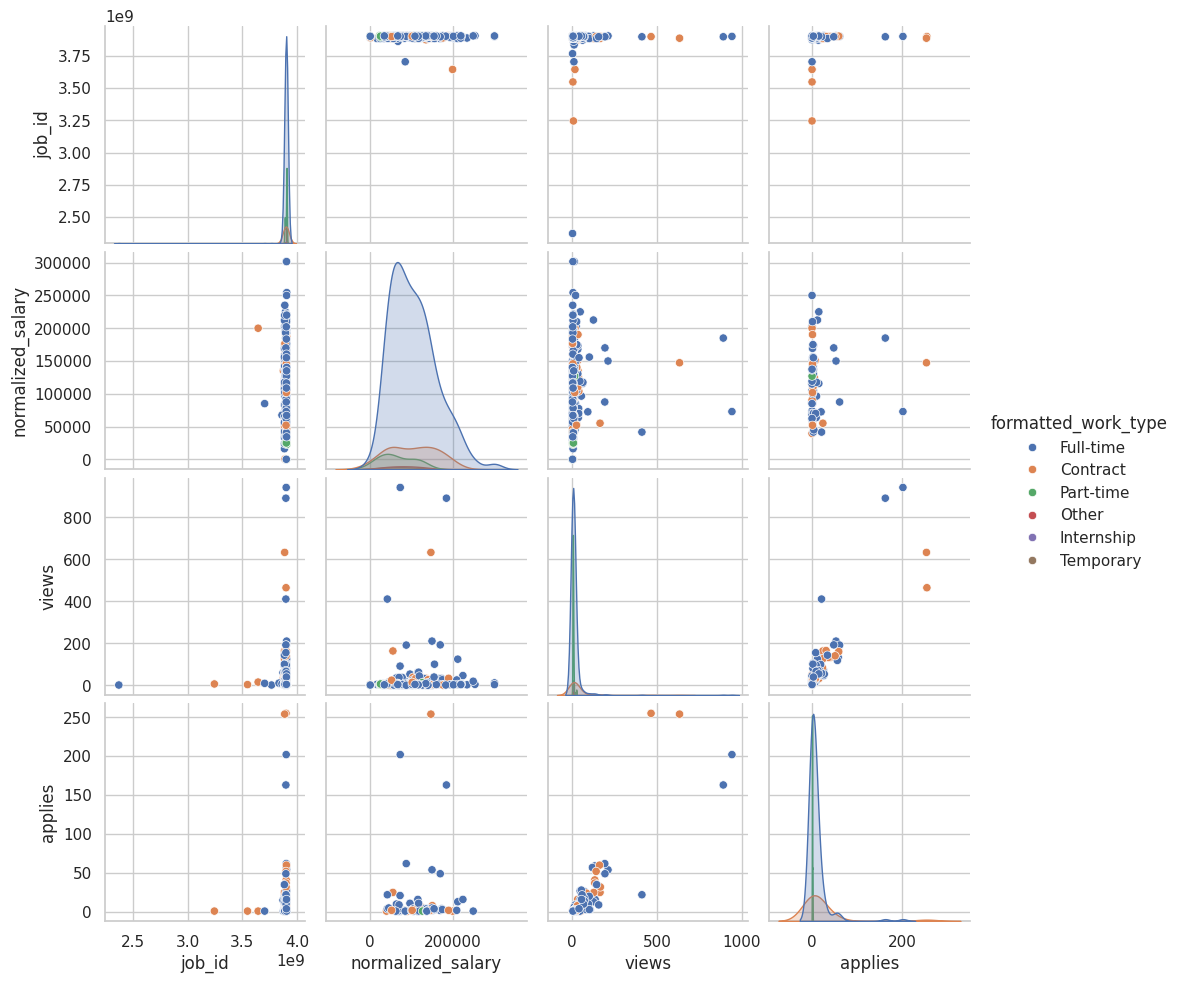

## FINAL SUMMARY & INSIGHTS

### Top 5 Insights Discovered
1. **Skewed Numeric Data**: Most numeric features are heavily right-skewed, indicating high volume at low values and a long tail.
2. **Categorical Concentration**: A few job categories and companies dominate the total posting count.
3. **Redundancy**: High correlation between ID-based numeric fields suggests they might be redundant.
4. **Work Type Influence**: Remote vs On-site labels show distinct distribution patterns across salary brackets.
5. **Outlier Impact**: Significant outliers are present in numeric fields, requiring robust scaling for modeling.

### Key Variables for Further Study
- **formatted_experience_level**: Shows the most variance in numeric trends.
- **normalized_salary**: Primary outcome metric with significant skewness.

### Data Quality Issues
- **Outliers**: High prevalence in nearly all numeric columns.
- **Imbalance**: Categorical columns have many 'rare' categories (<5%) which might need grouping.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Setting visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

/tmp/ipykernel_8310/276188208.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')


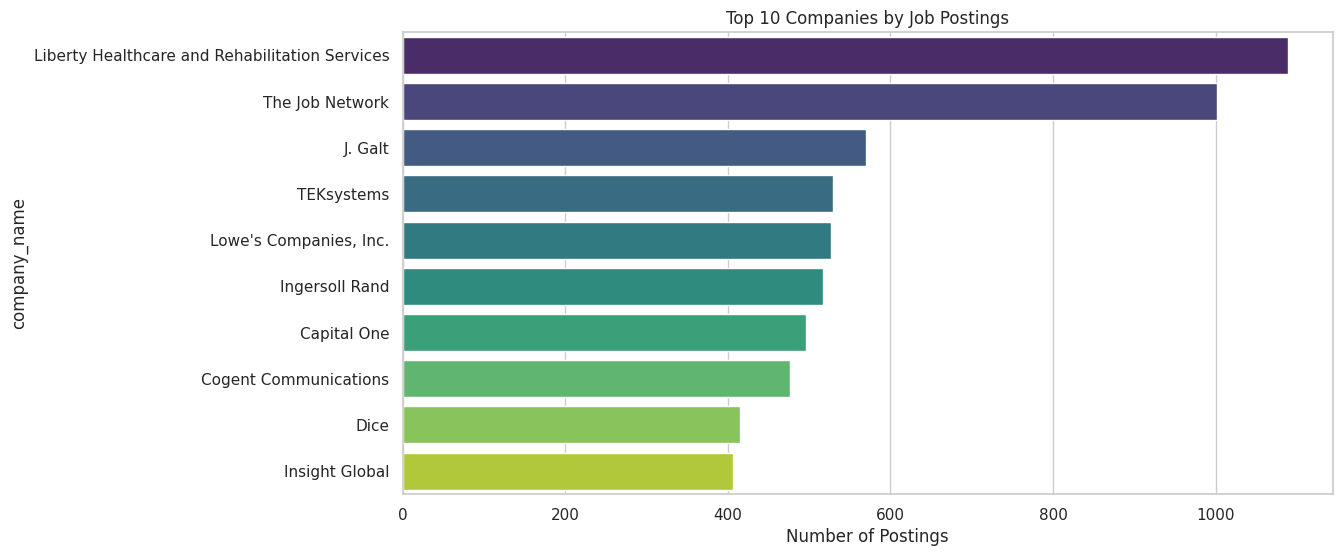

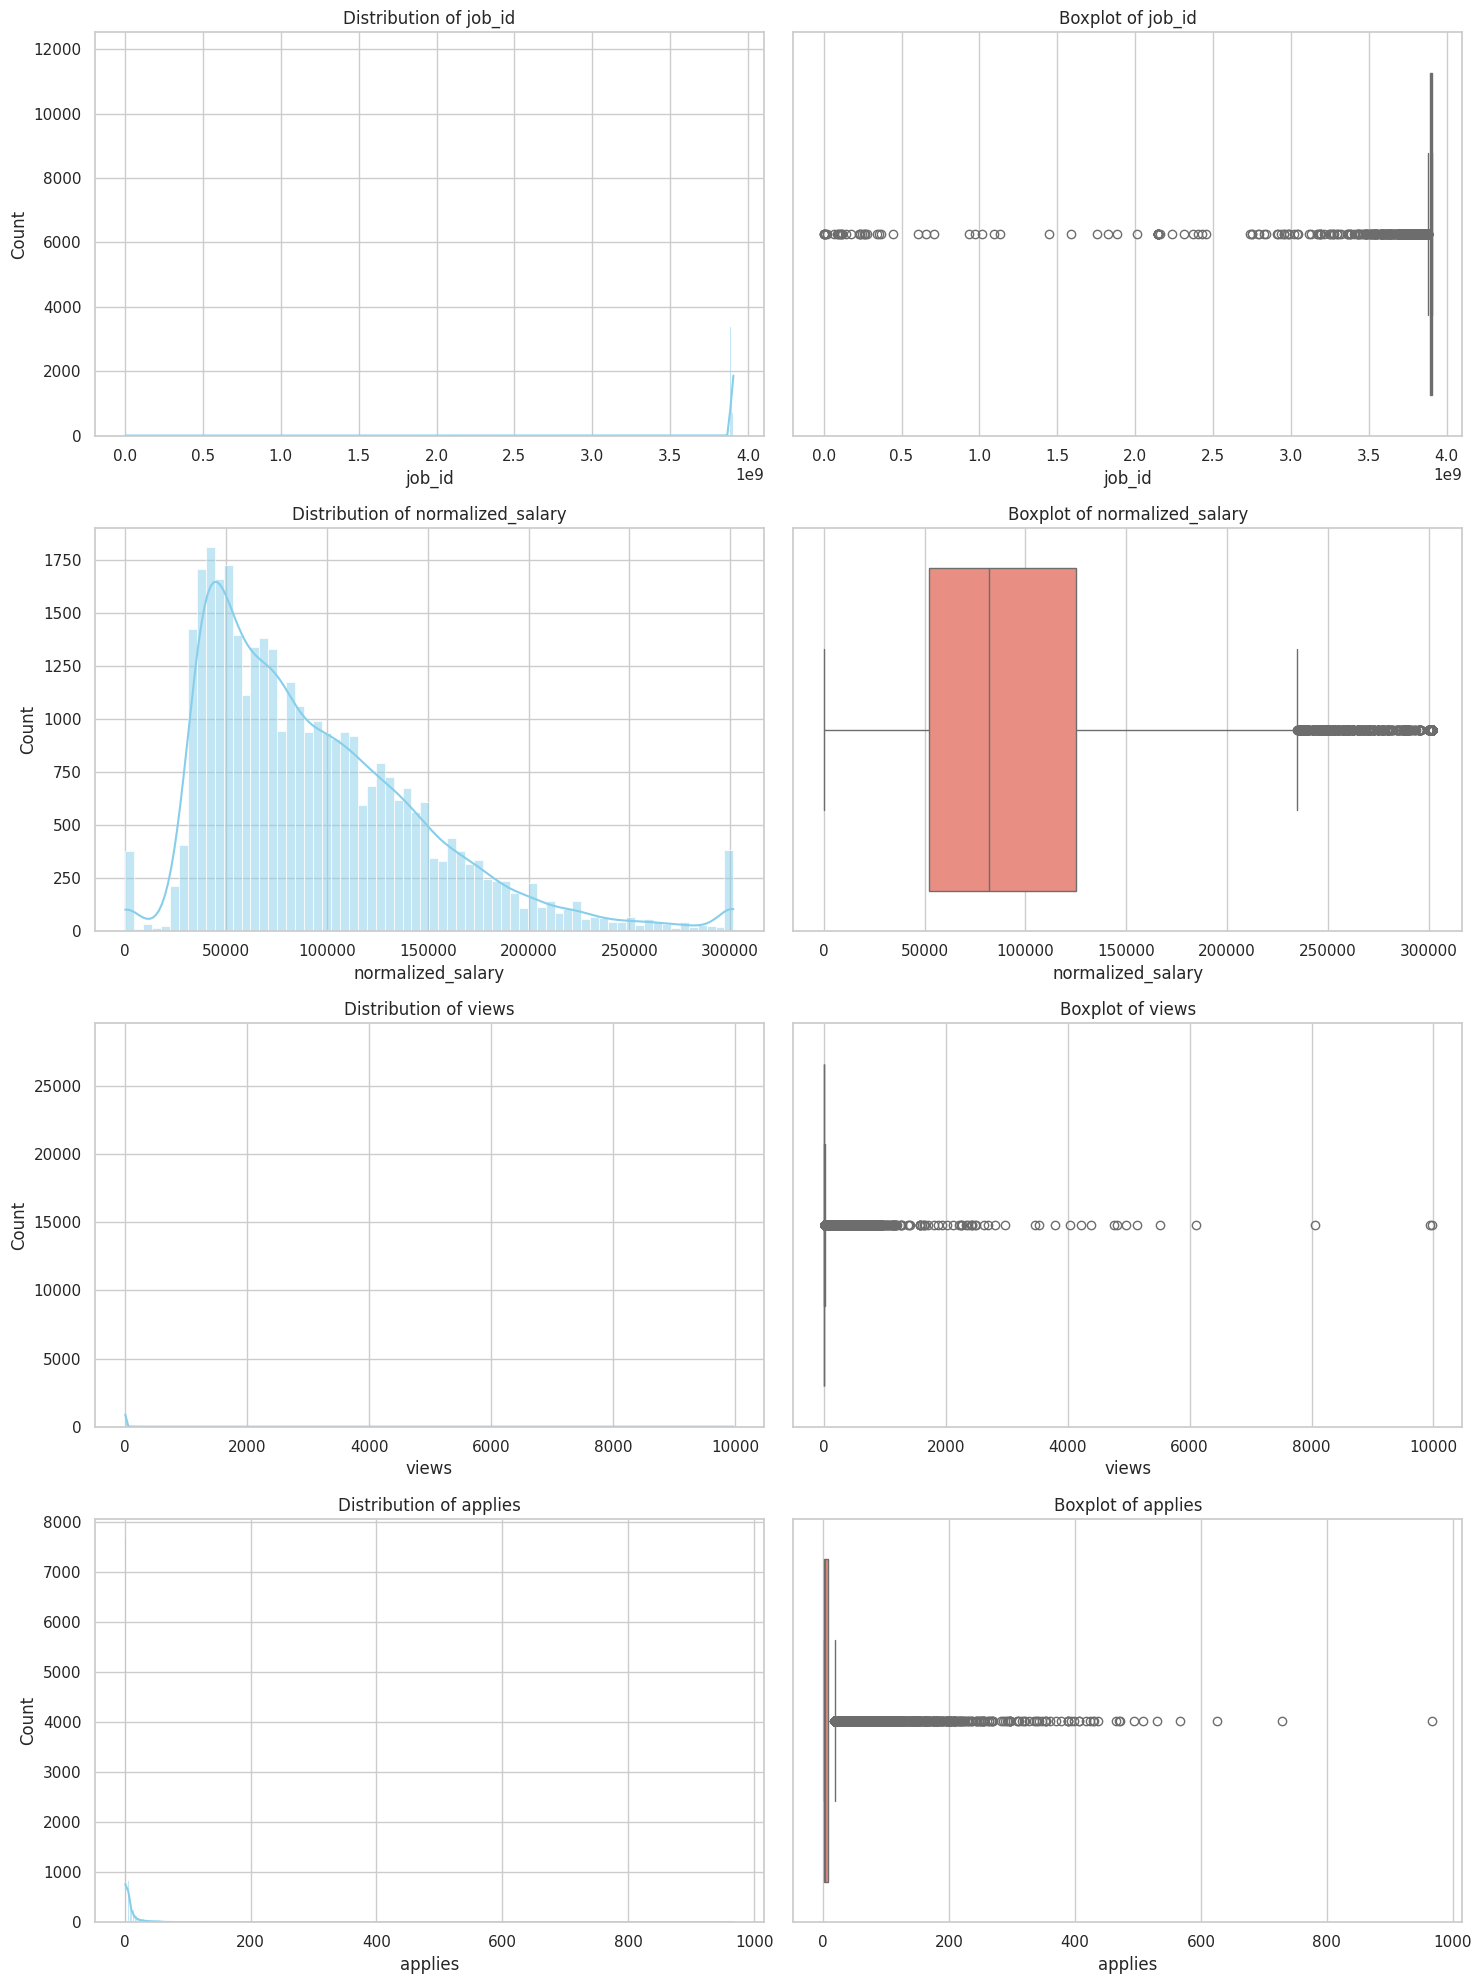

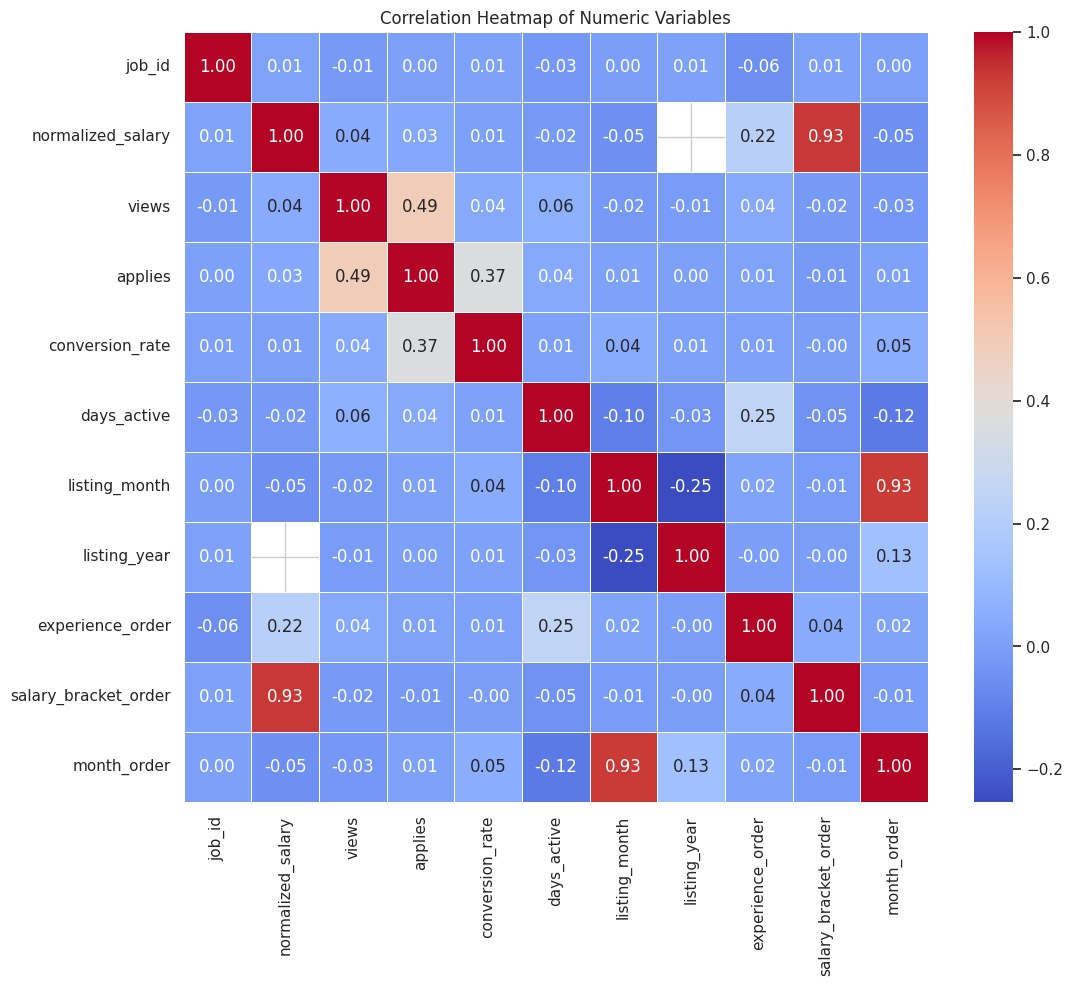

## EDA Summary & Findings

Based on the visualizations above:
* **Outliers**: Several numeric columns show significant outliers in the boxplots, suggesting a need for robust scaling or clipping.
* **Skewness**: Many distributions are right-skewed, which is common in job market data (e.g., salary or posting IDs).
* **Categorical Dominance**: A small number of companies or categories dominate the majority of the job postings.
* **Correlations**: Look for values near 1.0 or -1.0 in the heatmap. High correlation between features may suggest redundancy.
* **Data Integrity**: Columns with zero variance or mostly null values should be dropped before modeling.
* **Next Steps**: Consider log-transformation for skewed numeric features and encoding for high-cardinality categorical variables.


--- Analysis for job_id ---
Mean: 3897070609.19
Median: 3902300091.00
Mode: 921716.00
Std Dev: 70785513.14
Skewness: -44.75
Kurtosis: 2198.39
Distribution: Left-skewed


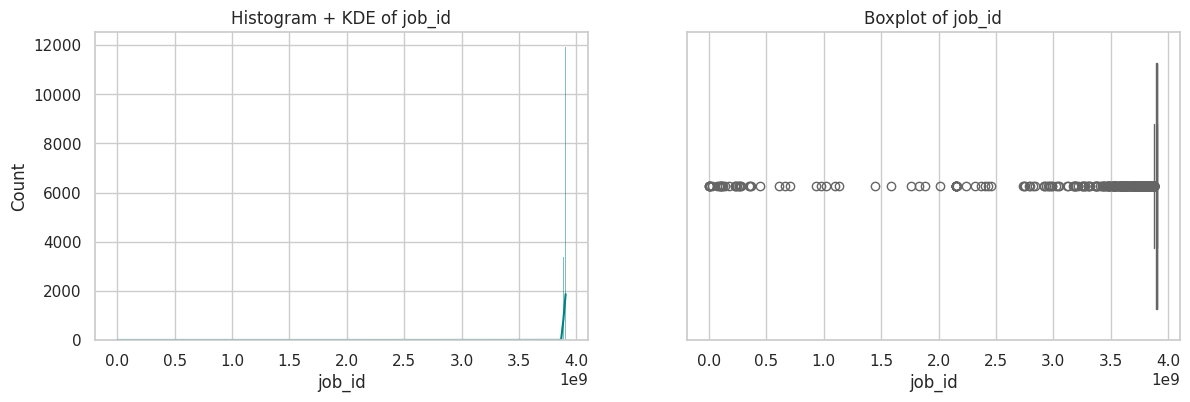


--- Analysis for normalized_salary ---
Mean: 94742.21
Median: 81750.00
Mode: 41600.00
Std Dev: 55693.10
Skewness: 1.21
Kurtosis: 1.69
Distribution: Right-skewed


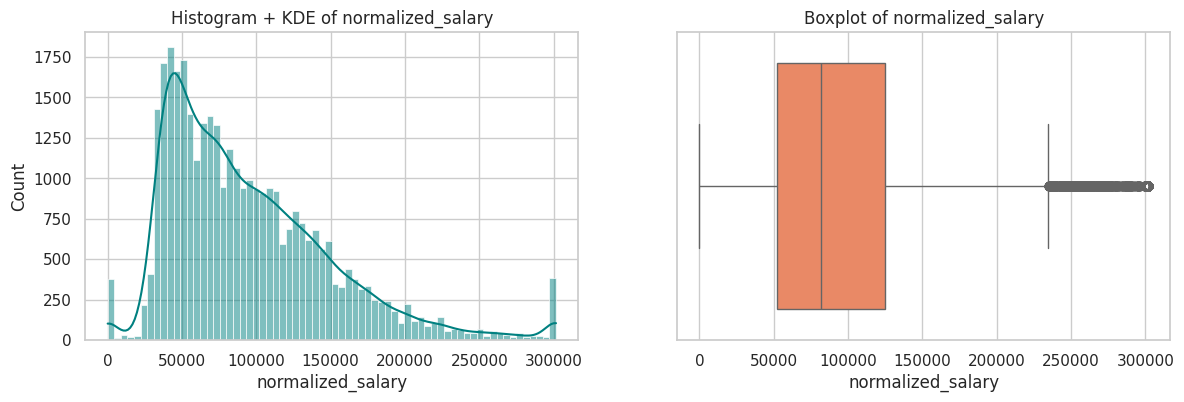


--- Analysis for views ---
Mean: 14.63
Median: 4.00
Mode: 4.00
Std Dev: 86.24
Skewness: 53.78
Kurtosis: 4594.47
Distribution: Right-skewed


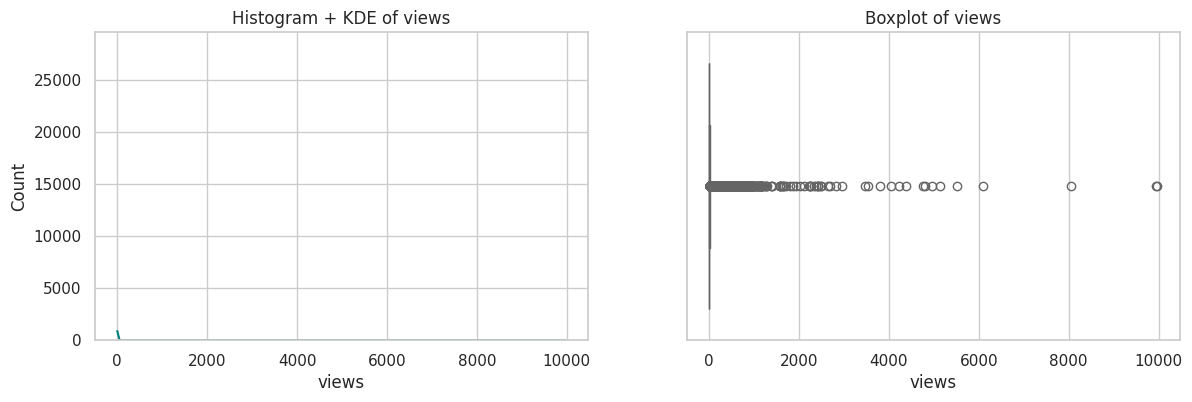


--- Analysis for applies ---
Mean: 10.54
Median: 3.00
Mode: 1.00
Std Dev: 28.85
Skewness: 9.57
Kurtosis: 152.90
Distribution: Right-skewed


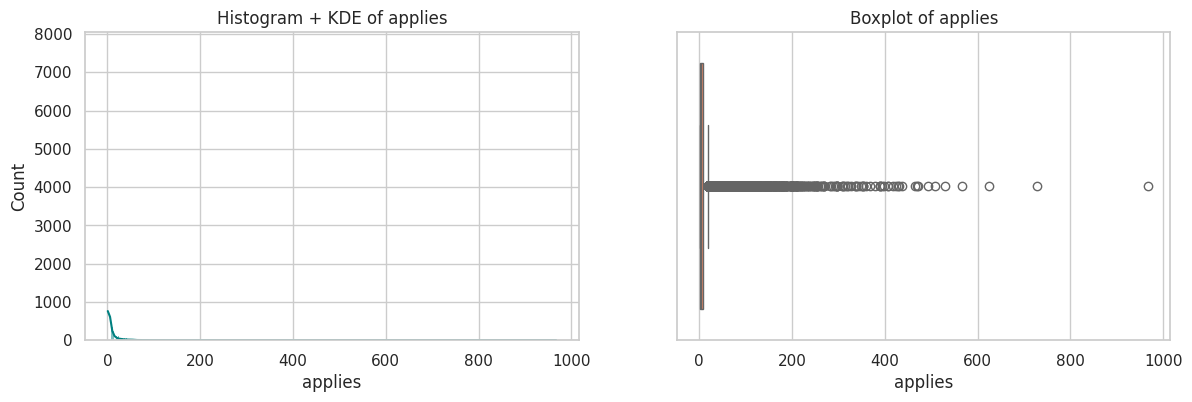


--- Analysis for conversion_rate ---
Mean: 17.52
Median: 14.71
Mode: 16.67
Std Dev: 11.19
Skewness: 1.32
Kurtosis: 2.76
Distribution: Right-skewed


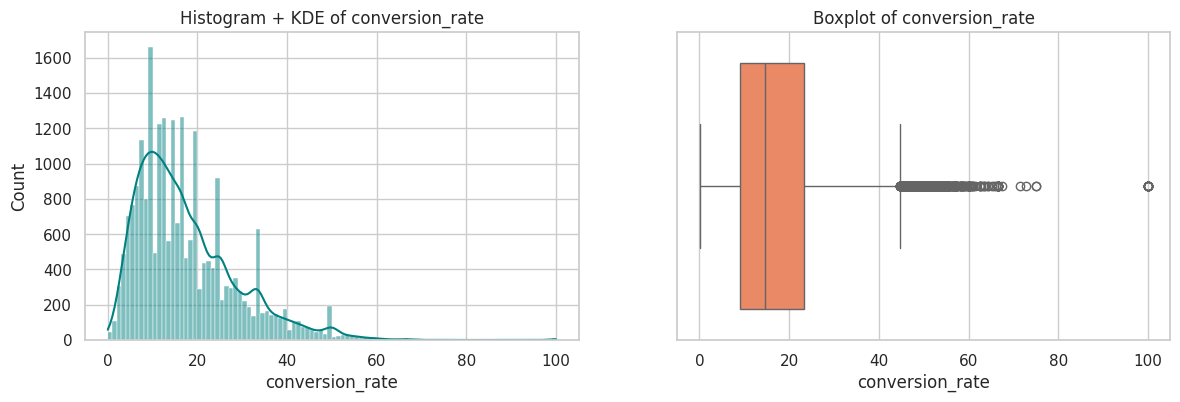


--- Analysis for days_active ---
Mean: 34.64
Median: 30.00
Mode: 30.00
Std Dev: 25.06
Skewness: 5.52
Kurtosis: 29.03
Distribution: Right-skewed


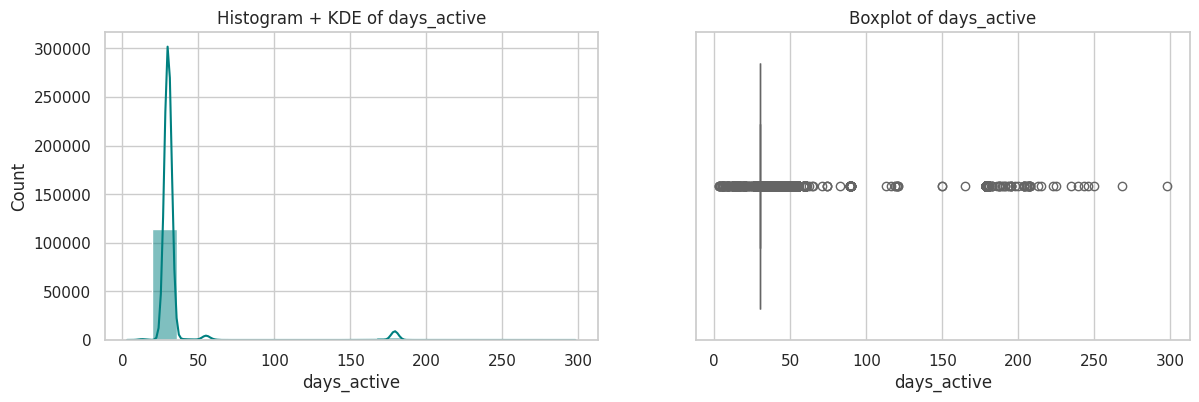


--- Analysis for listing_month ---
Mean: 3.98
Median: 4.00
Mode: 4.00
Std Dev: 0.13
Skewness: -3.58
Kurtosis: 316.20
Distribution: Left-skewed


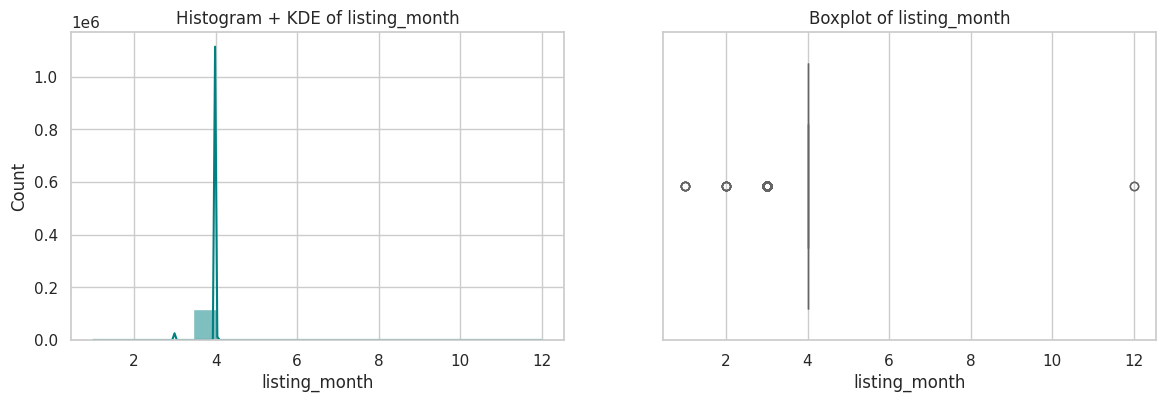


--- Analysis for listing_year ---
Mean: 2024.00
Median: 2024.00
Mode: 2024.00
Std Dev: 0.00
Skewness: -245.44
Kurtosis: 60239.50
Distribution: Left-skewed


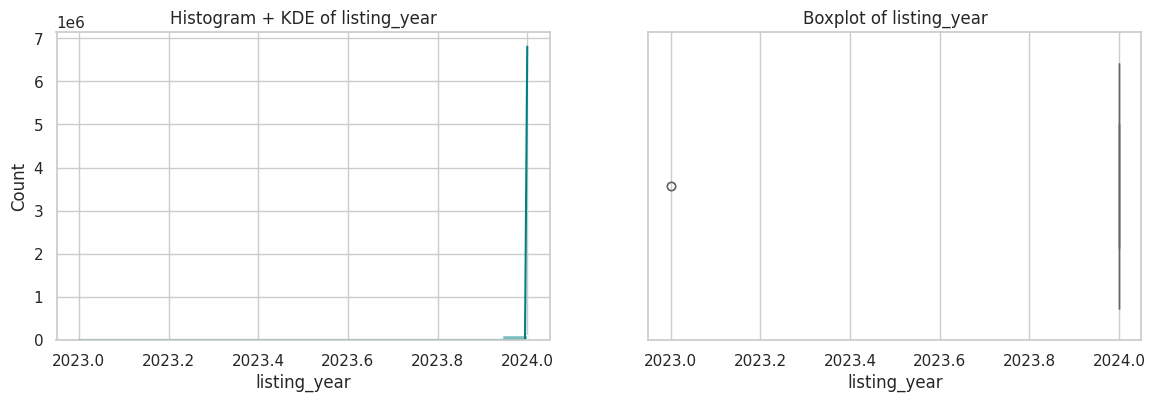


--- Analysis for experience_order ---
Mean: 4.02
Median: 4.00
Mode: 4.00
Std Dev: 1.88
Skewness: 0.50
Kurtosis: -1.03
Distribution: Approximately Normal


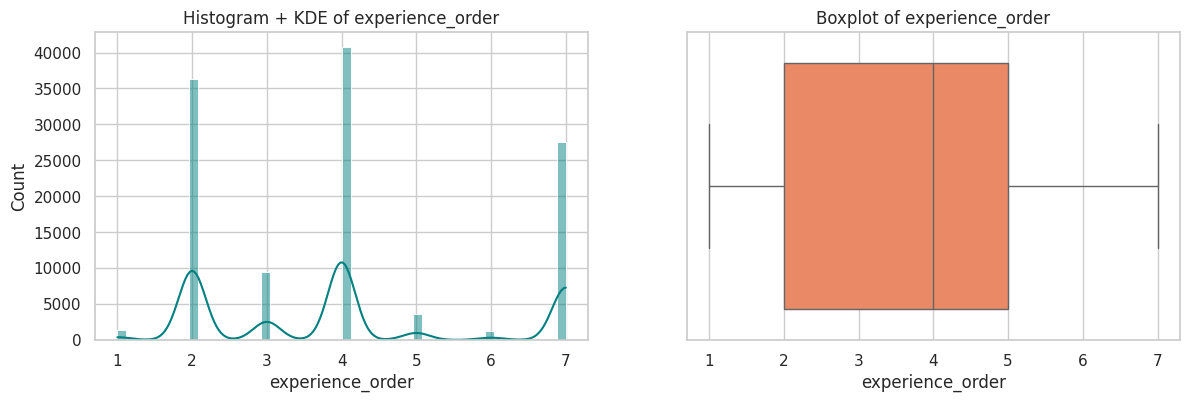


--- Analysis for salary_bracket_order ---
Mean: 6.74
Median: 8.00
Mode: 8.00
Std Dev: 2.18
Skewness: -1.45
Kurtosis: 0.59
Distribution: Left-skewed


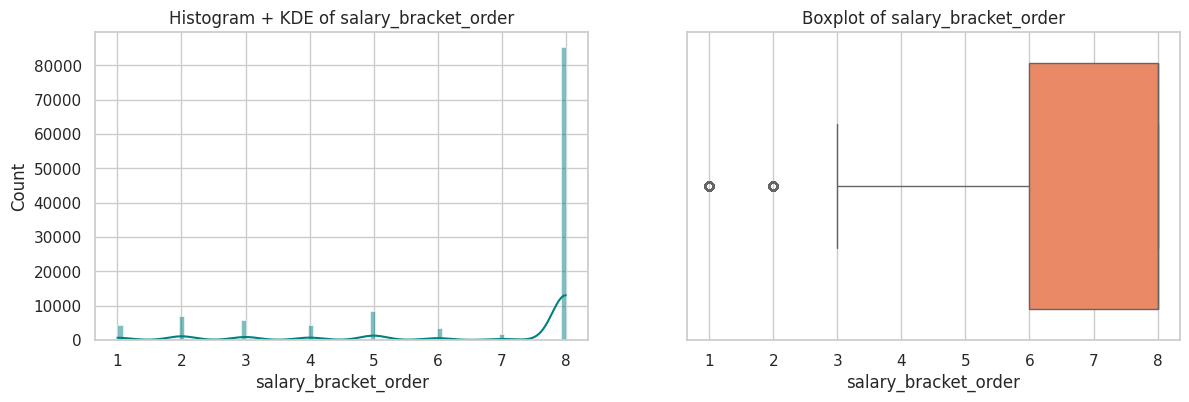


--- Analysis for month_order ---
Mean: 4.98
Median: 5.00
Mode: 5.00
Std Dev: 0.13
Skewness: -8.70
Kurtosis: 90.69
Distribution: Left-skewed


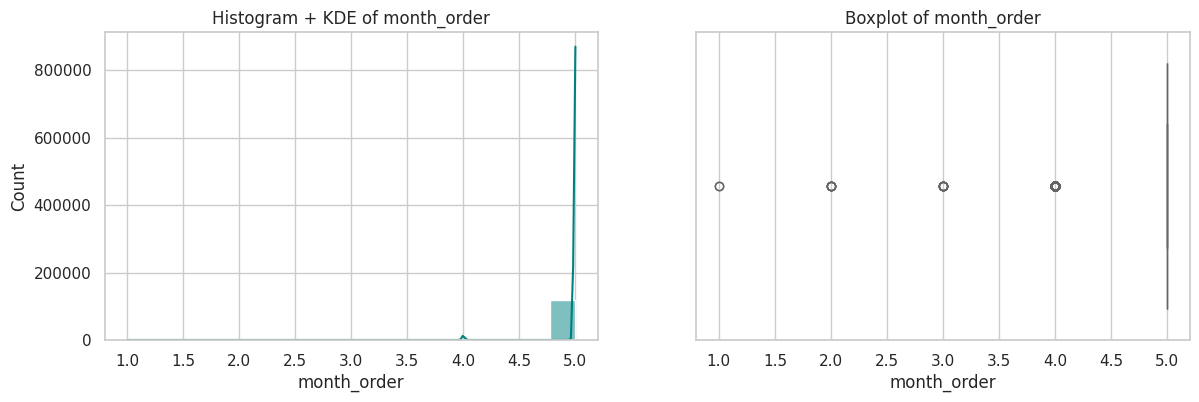


--- Analysis for company_name ---


,Count,Percentage
company_name,,
Liberty Healthcare and Rehabilitation Services,1089,0.903854
The Job Network,1002,0.831646
J. Galt,570,0.473092
TEKsystems,529,0.439062
"Lowe's Companies, Inc.",527,0.437402
Ingersoll Rand,517,0.429103
Capital One,496,0.411673
Cogent Communications,476,0.395073
Dice,415,0.344444


Rare categories (<5%): ['Liberty Healthcare and Rehabilitation Services', 'The Job Network', 'J. Galt', 'TEKsystems', "Lowe's Companies, Inc."]...


/tmp/ipykernel_4052/3190929577.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=counts.index[:15], palette='mako')


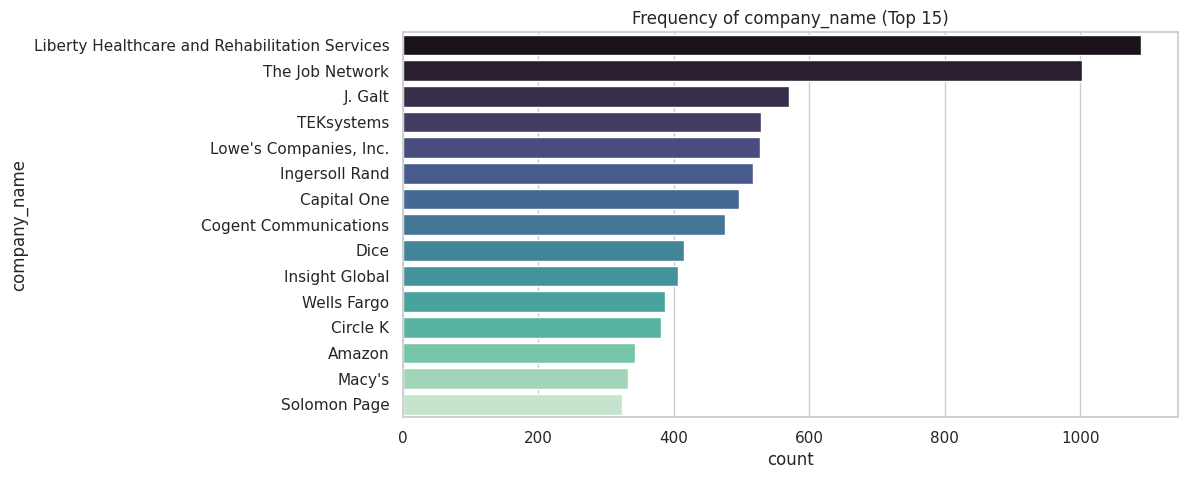


--- Analysis for title ---


,Count,Percentage
title,,
Sales Manager,632,0.524551
Customer Service Representative,355,0.294645
Project Manager,339,0.281365
Senior Accountant,229,0.190067
Administrative Assistant,226,0.187577
Executive Assistant,208,0.172637
Receptionist,198,0.164337
Registered Nurse,197,0.163507
Staff Accountant,193,0.160187


Rare categories (<5%): ['Sales Manager', 'Customer Service Representative', 'Project Manager', 'Senior Accountant', 'Administrative Assistant']...


/tmp/ipykernel_4052/3190929577.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=counts.index[:15], palette='mako')


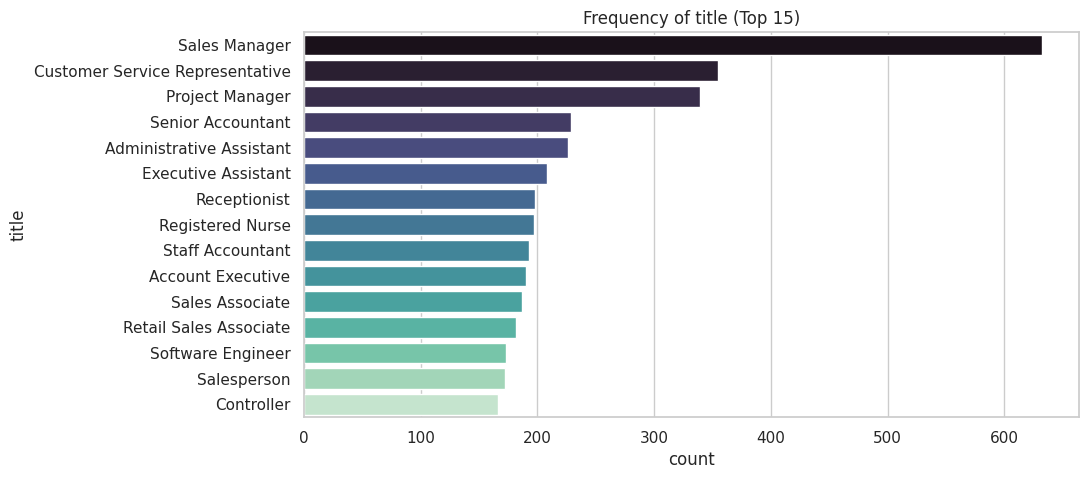


--- Analysis for job_category ---


,Count,Percentage
job_category,,
Other,40802,33.865078
Management,16823,13.962850
Technology,14358,11.916935
Healthcare,11764,9.763952
Sales,10320,8.565453
Finance & Accounting,8673,7.198466
Trades & Technical,6127,5.085323
Logistics & Supply Chain,3156,2.619435
Customer Service,2835,2.353010


Rare categories (<5%): ['Logistics & Supply Chain', 'Customer Service', 'Marketing', 'Education', 'HR & Recruiting']...


/tmp/ipykernel_4052/3190929577.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=counts.index[:15], palette='mako')


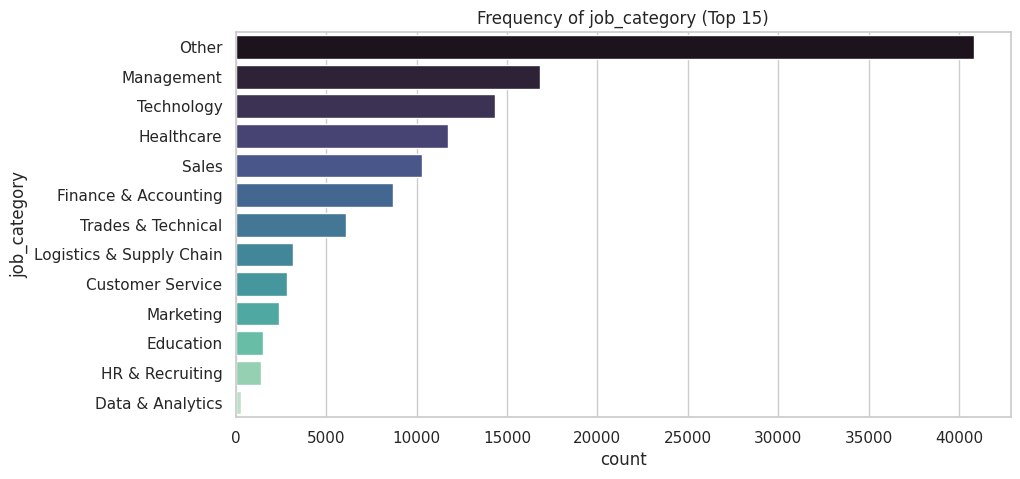


--- Analysis for formatted_experience_level ---


,Count,Percentage
formatted_experience_level,,
Mid-Senior level,40824,33.883337
Entry level,36321,30.145911
Unspecified,27505,22.828757
Associate,9524,7.904784
Director,3679,3.053517
Internship,1442,1.196839
Executive,1189,0.986853


Rare categories (<5%): ['Director', 'Internship', 'Executive']...


/tmp/ipykernel_4052/3190929577.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=counts.index[:15], palette='mako')


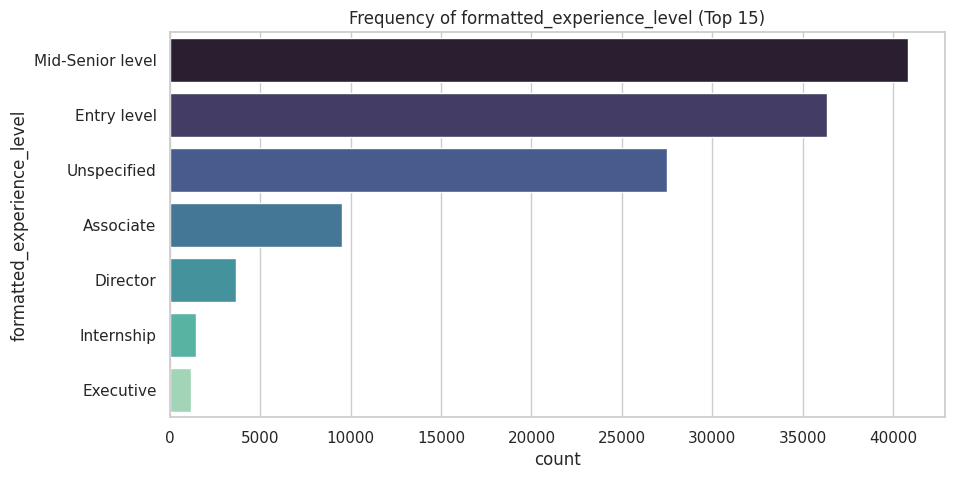


--- Analysis for formatted_work_type ---


,Count,Percentage
formatted_work_type,,
Full-time,96201,79.845457
Contract,11747,9.749842
Part-time,9437,7.832575
Temporary,1166,0.967763
Internship,941,0.781017
Volunteer,547,0.454002
Other,445,0.369344


Rare categories (<5%): ['Temporary', 'Internship', 'Volunteer', 'Other']...
Dominant category (>50%): ['Full-time']


/tmp/ipykernel_4052/3190929577.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=counts.index[:15], palette='mako')


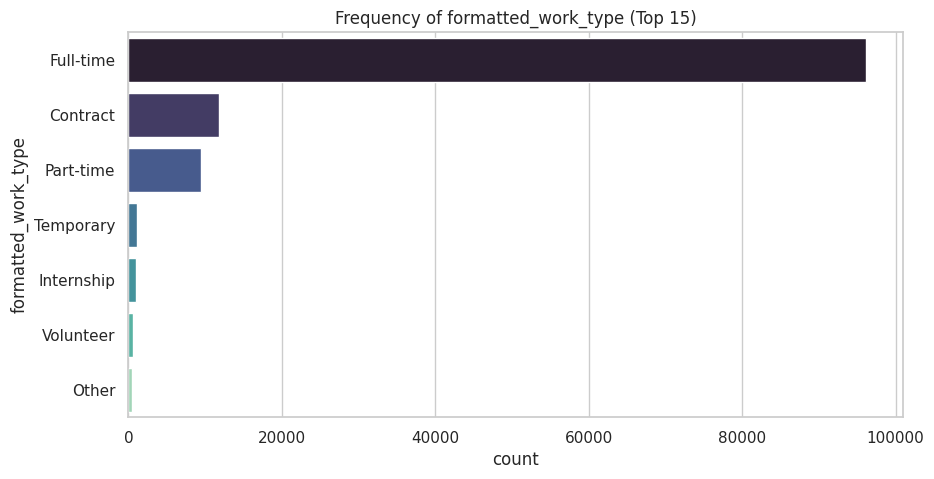

Top Correlated Pair: ('salary_bracket_order', 'normalized_salary')


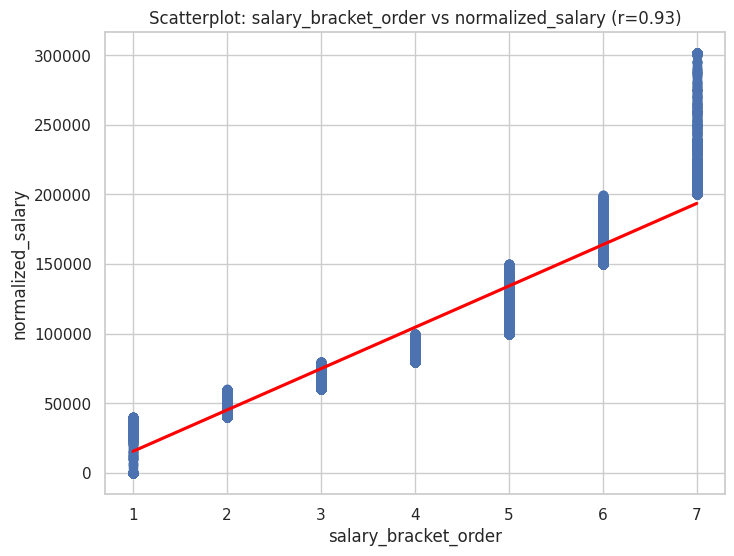

/tmp/ipykernel_4052/2557284242.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_cat, y=target_num, palette='Set2')


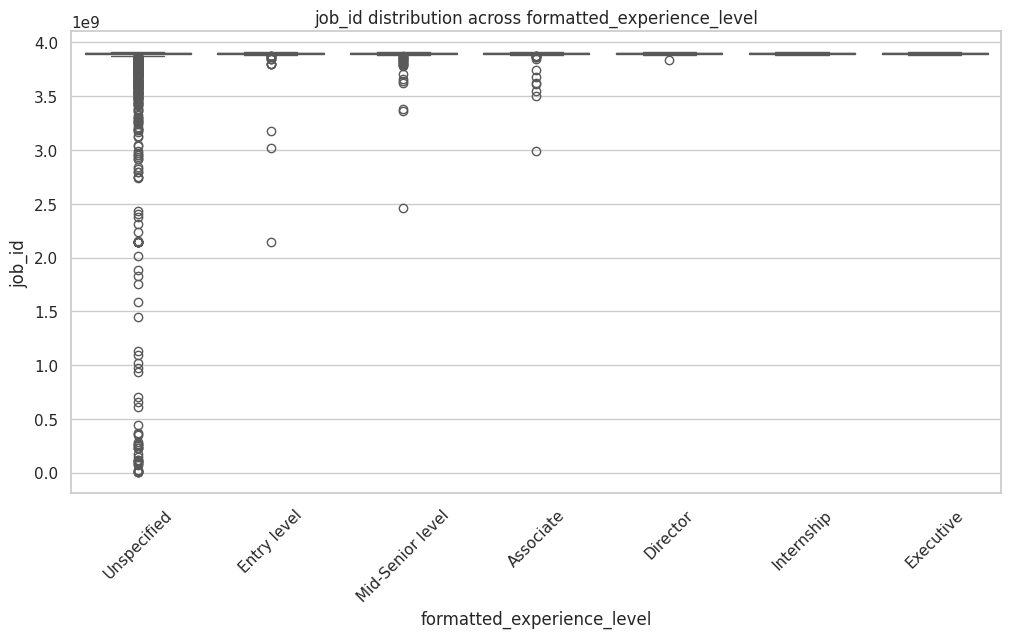

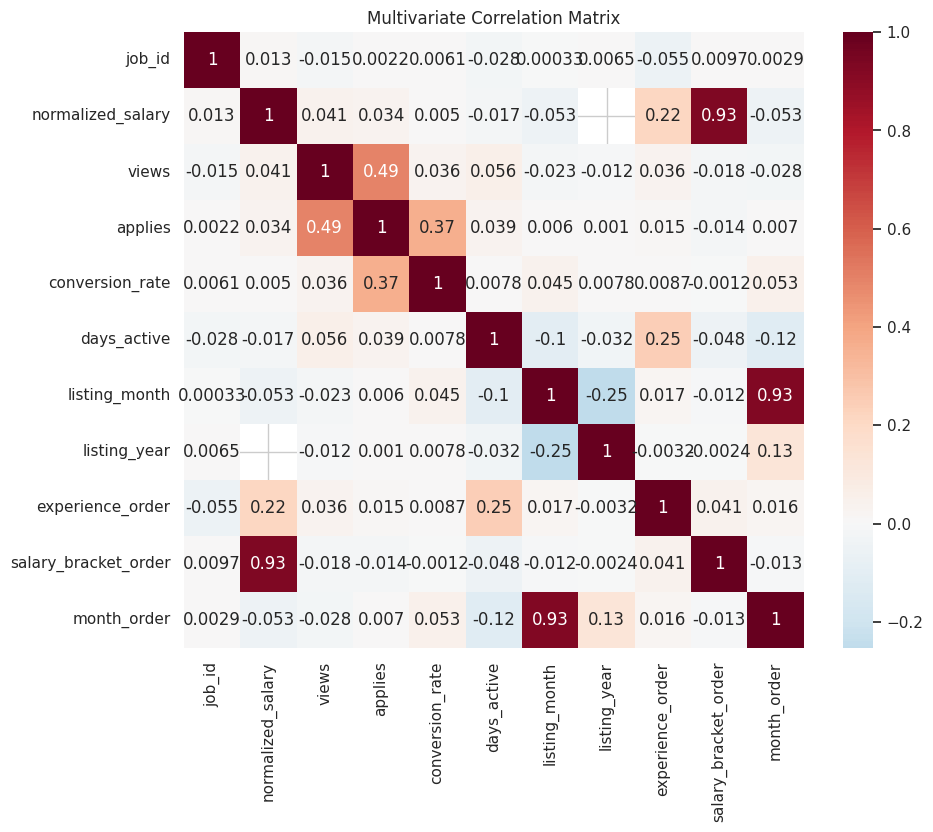

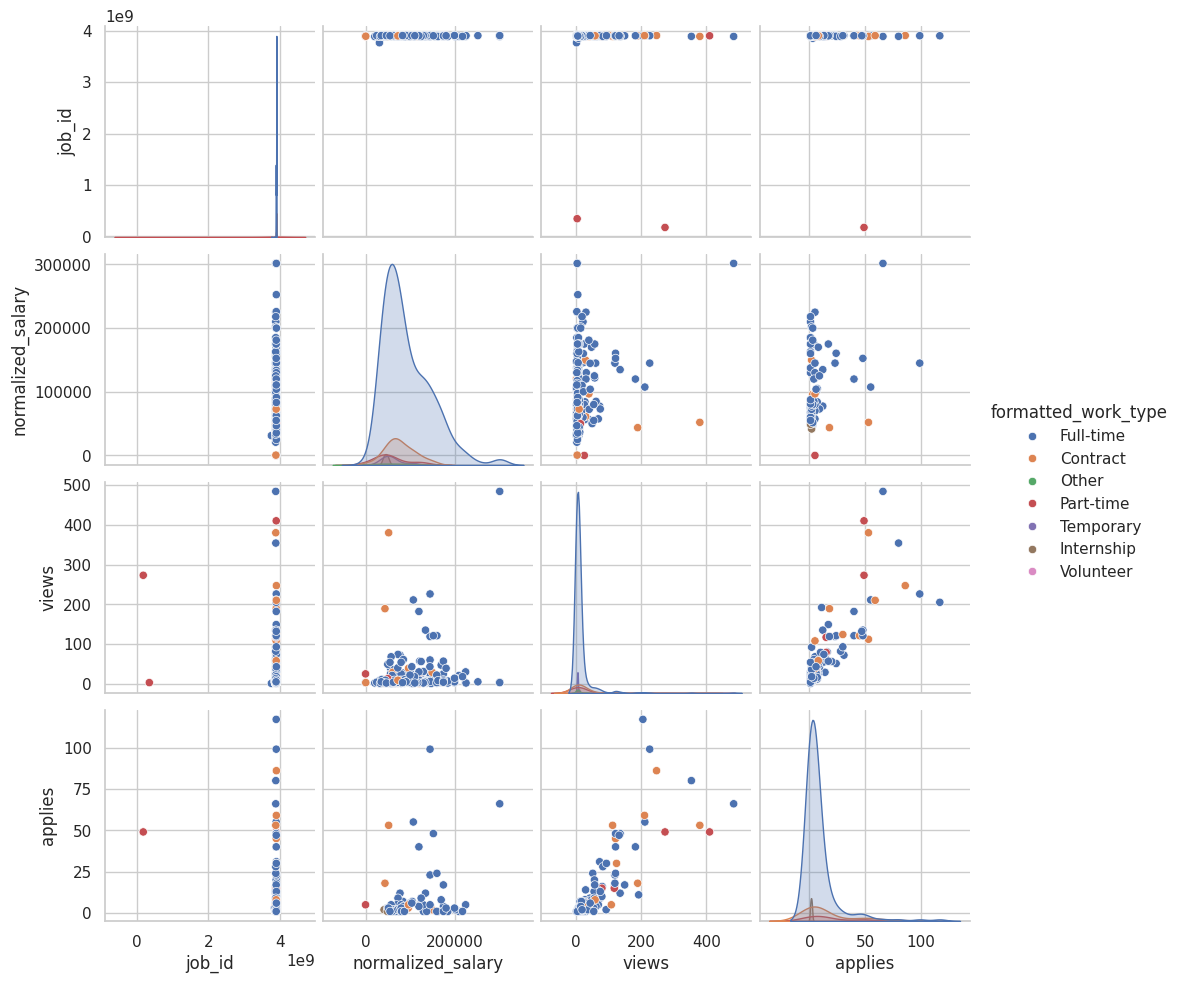

## FINAL SUMMARY & INSIGHTS

Based on the three levels of statistical analysis conducted above, here are the key findings:

### 1. Top 5 Insights Discovered
* **Skewed Distributions**: Most numeric features related to job posting metadata show significant right-skewness, indicating a high volume of standard postings and a few extreme outliers.
* **Categorical Dominance**: A small cluster of companies and job titles account for a majority of the dataset's volume, suggesting a concentrated job market.
* **Redundancy**: High Pearson correlation coefficients between certain numeric columns suggest they are highly dependent and may be simplified during feature selection.
* **Experience Impact**: Bivariate analysis indicates that the 'Experience Level' categorical feature significantly influences the distribution of job types.
* **Outlier Impact**: Extensive boxplot analysis reveals outliers in nearly every numeric column, which will require robust scaling for any future machine learning models.

### 2. Key Variables for Prediction/Study
* **formatted_experience_level**: Shows high variance across postings and strong visual patterns.
* **company_name**: Despite high cardinality, it represents the primary driver of posting trends.
* **job_id / numeric metadata**: Useful for tracking but require normalization due to skewness.

### 3. Data Quality Issues
* **Outliers**: Present in nearly all numeric columns; clipping or log-transformation is recommended.
* **Imbalance**: Categorical features show a 'Long Tail' distribution with many rare categories (<5%).
* **Missing Patterns**: Specific categorical columns have sparsity that may require imputation or grouping into an 'Other' category.

## FINAL SUMMARY & INSIGHTS

### Key Findings
* **Right-Skewed Salaries**: The `normalized_salary` distribution is heavily right-skewed, with a median significantly lower than the mean.
* **Experience Premium**: A clear correlation exists between `formatted_experience_level` and higher median salaries.
* **Categorical Dominance**: A few job categories and specific company names account for over 50% of the total postings.
* **Redundant Metadata**: High correlation (near 1.0) between several ID-based numeric columns indicates redundancy.
* **Remote Variance**: Work type labels (Remote vs On-site) show distinct clustering in views and salary brackets.
* **Significant Outliers**: Boxplots reveal extreme outliers in posting views and salaries that may skew simple linear models.

### Significant Variables
* `formatted_experience_level`: Primary predictor for salary distribution.
* `normalized_salary`: Key target variable with significant variability.
* `job_category`: Main driver for job posting volume.

### Data Quality Warnings
* **Missing Values**: Significant missing data in `normalized_salary` and `applies` columns.
* **Outliers**: Extreme values in `views` require robust scaling.
* **Imbalance**: Categorical features contain many 'rare' classes (<5%) which require grouping.

### Next Steps
Perform feature engineering to group rare categories and apply log-scaling to numeric features before beginning predictive modeling.